# **fMRI Image Analysis**

## Overview

This notebook is authored by: Lucas Nafe

## Objectives

My aim for this project is to train and compare two separate machine learning models, K-Nearest Neighbors and  two separate variants of neural networks (Multi-layered preceptron and Convolutional), on their performance over four different types of fMRI images of brain tumors: glioma, meningioma, pituitary, and no tumor (healthy). I will test and run several different hyperparameters for each model over training and validation data, to find the optimal constraints that produce the highest model performance on my testing data. I want to find the best model for analyzing fMRI data for applications in research, education, and medical fields. 

## Why Should We Use Machine Learning?

Using machine learning to analyze fMRI scans can improve accuracy by detecting subtle patterns in brain activity that may be difficult for humans to recognize, leading to earlier and more reliable tumor identification. It can also speed up diagnosis by automating image analysis, allowing clinicians to focus on treatment decisions. Additionally, these models can continuously improve as they learn from more data, enhancing performance over time.


## Background

### Glioma Tumors
Glioma tumors are tumors arising from glial cells, often caused by genetic mutations, and are primarily located in the brain or spinal cord.

<img src="https://www.cancer.gov/PublishedContent/Images/nci/rare-brain-spine-tumor/tumors/diffuse-midline-gliomas/Midline%20Glioma%20(Article).__v200164019.jpg" width="254" height="254">

### Meningioma Tumors

Meningioma tumors are usually benign tumors caused by abnormal cell growth in the meninges (the membranes surrounding the brain and spinal cord), and are most often found on the brain’s outer surface.

<img src="https://media.sciencephoto.com/image/c0472765/800wm/C0472765-Meningioma_brain_tumour,_MRI_scan.jpg" width="254" height="254">


### Pituitary Tumors

Pituitary Tumors are tumors caused by abnormal growth of cells in the pituitary gland, located at the base of the brain. These tumors often affect hormone production.

<img src="https://cdn.lecturio.com/assets/MRI-pituitary-tumor-sagittal-view.jpg" width="254" height="254">

## Data Description

My dataset provides a comprehensive collection of fMRI images for the classification and segmentation of brain tumors. My data consists of 7,153 features split into 4 separate classes: glioma, meningioma, pituitary, and no tumor (healthy brain). The images are 254x254 and are formatted in jpg, but will be resized to 128x128 during training and testing. This data will help find the best machine learning model for analyzing fMRI images.

Some factors that may lead to misclassification include similarities in color, texture, and overall visual features between different tumor classes, which can make it difficult for the model to clearly distinguish them. Also, very small tumors or tumors with unclear boundaries may not contain enough visible detail for accurate identification. Variations in image quality, contrast, and scan orientation could also reduce the model’s ability to consistently classify the tumors correctly.


## Methods

For this project, I will evaluate and compare the performance of several K-Nearest Neighbors (KNN) baseline models and convolutional neural network (CNN) baseline models for fMRI image analysis. The goal is to assess how traditional machine learning methods and deep learning approaches differ in their ability to accurately classify brain tumor images.

*KNN Baseline*:
- KNN model with no preprocessing prior to training

*KNN Main Method*:
- KNN model using preprocessed data with HOG feature extraction


*Neural Network Baseline*:
- A fully multi-layered preceptron (MLP) trained over varying numbers of epochs and learning rates

*Neural Network Main Method*:
- A simple CNN trained over varying learning rates and a fixed number of epochs (30).





## Importing Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

### Helper Function to Load Data

In [ ]:
def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

Loading data to visualize Train/Test Shape

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')

print(f'Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}')

Training data shape: (5723, 128, 128, 3), Training labels shape: (5723,)
Testing data shape: (1430, 128, 128, 3), Testing labels shape: (1430,)


### Viewing Images and Correct Class Labeling

Viewing a random training image:


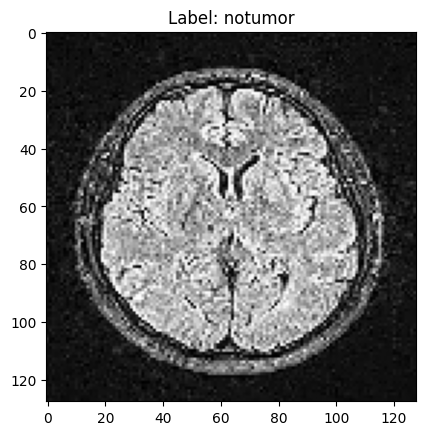

Viewing multiple random training images:


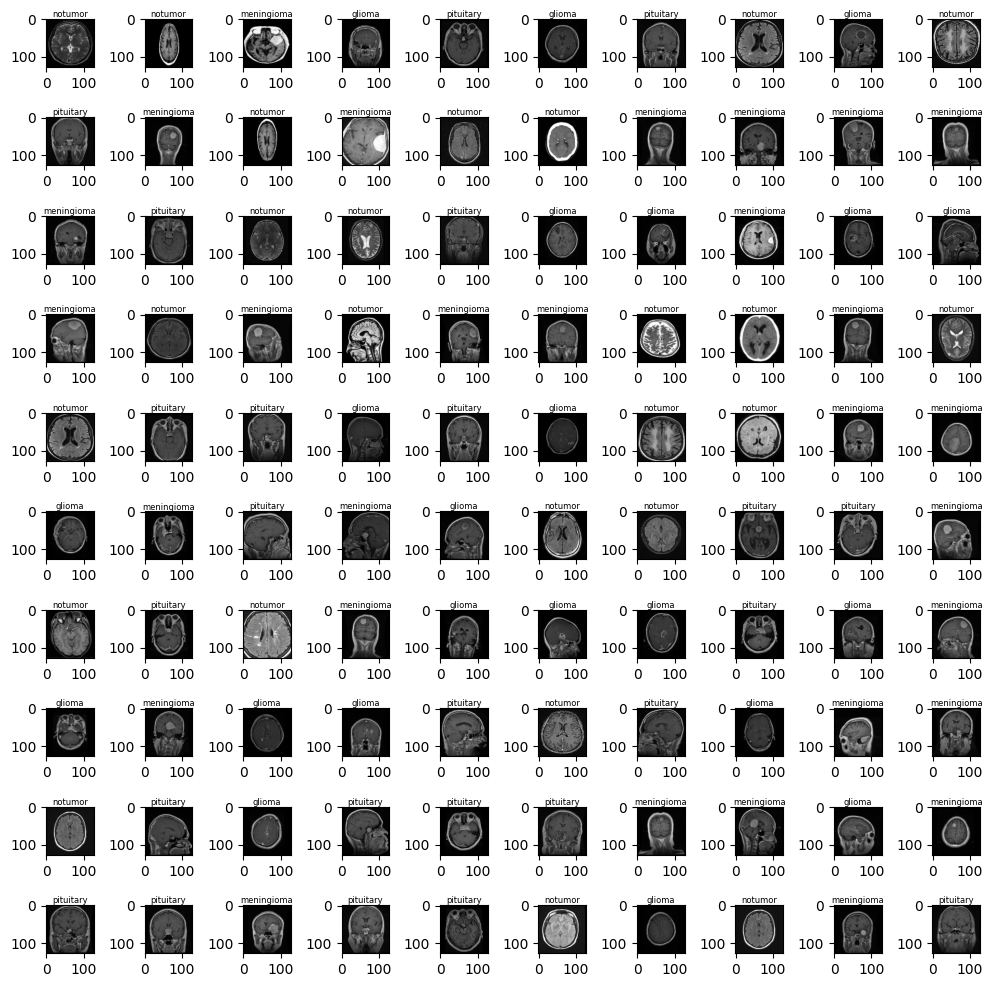

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import random


def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')


print("Viewing a random training image:")
idx = random.randint(0, len(X_train) - 1)
plt.imshow(X_train[idx])
plt.title(f'Label: {y_train[idx]}')
plt.show()

print("Viewing multiple random training images:")

plt.figure(figsize=(10, 10))

for i in range(100):
    idx = random.randint(0, len(X_train) - 1)
    plt.subplot(10, 10, i + 1)
    plt.imshow(X_train[idx])
    plt.title(y_train[idx], fontsize=6, pad=1)


plt.tight_layout()
plt.show()



## K-Nearest Neighbors Before Preprocessing

k=1, Accuracy: 0.9524
k=2, Accuracy: 0.9203
k=3, Accuracy: 0.9140
k=4, Accuracy: 0.8860
k=5, Accuracy: 0.8832
k=6, Accuracy: 0.8629
k=7, Accuracy: 0.8608
k=8, Accuracy: 0.8441
k=9, Accuracy: 0.8427
k=10, Accuracy: 0.8315
k=11, Accuracy: 0.8336
k=12, Accuracy: 0.8217
k=13, Accuracy: 0.8203
k=14, Accuracy: 0.8049


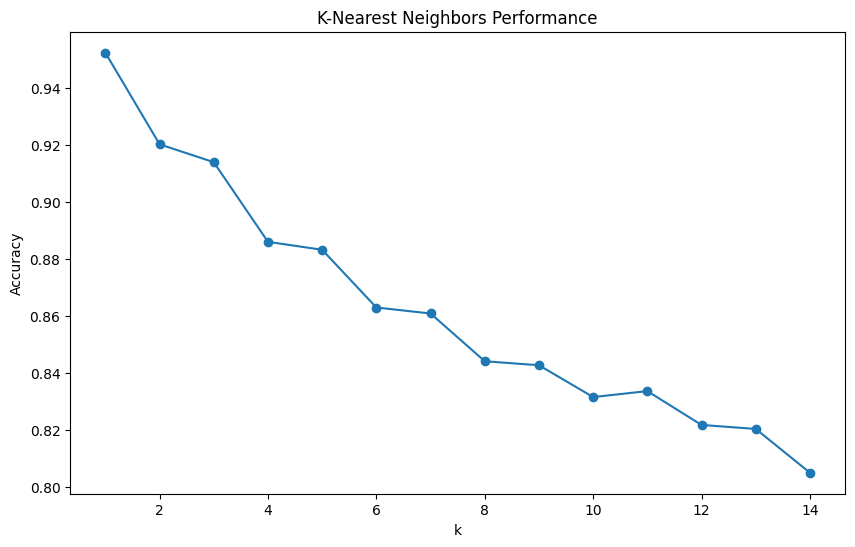

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')


from sklearn.neighbors import KNeighborsClassifier

k_values = range(1, 15)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train.reshape(X_train.shape[0], -1), y_train)
    accuracy = knn.score(X_test.reshape(X_test.shape[0], -1), y_test)
    accuracies.append(accuracy)
    print(f'k={k}, Accuracy: {accuracy:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('K-Nearest Neighbors Performance')
plt.show()


### Discussion of Results

For this baseline trial, I ran the K-Nearest Neighbors classifier over different values of *k* from 1 to 14. k=1 exhibited the highest accuracy with 95.24% accuracy, and k=14 with the lowest accuracy of 80.49%. As depicted by the plot, as the values of *k* increased, the overall performance decreased, showing a negative correlation between the increase in *k* and model performance.

## K-Nearest Neighbors With Preprocessing and HOG Feature Extraction

### Preprocessing Methods

Here I implemented a histogram of oriented gradients (HOG). HOG feature extraction involves calculating the gradient magnitude and orientation for each pixel in an image, then dividing the image into small cells to create histograms of these gradients. The resulting histograms are concatenated to form a feature vector that describes the shape and appearance of objects in the image, which is useful for tasks like object detection.

I then standardized the feature set using a StandardScaler from sklearn.preprocessing over the HOG features to help prevent data leakage.

k=1, Train Accuracy: 1.0000, Test Accuracy: 0.9776
k=2, Train Accuracy: 0.9942, Test Accuracy: 0.9678
k=3, Train Accuracy: 0.9851, Test Accuracy: 0.9510
k=4, Train Accuracy: 0.9773, Test Accuracy: 0.9455
k=5, Train Accuracy: 0.9630, Test Accuracy: 0.9357
k=6, Train Accuracy: 0.9553, Test Accuracy: 0.9308
k=7, Train Accuracy: 0.9432, Test Accuracy: 0.9189
k=8, Train Accuracy: 0.9381, Test Accuracy: 0.9133
k=9, Train Accuracy: 0.9247, Test Accuracy: 0.9000
k=10, Train Accuracy: 0.9224, Test Accuracy: 0.9021
k=11, Train Accuracy: 0.9104, Test Accuracy: 0.8923
k=12, Train Accuracy: 0.9102, Test Accuracy: 0.8888
k=13, Train Accuracy: 0.9016, Test Accuracy: 0.8881
k=14, Train Accuracy: 0.8988, Test Accuracy: 0.8860


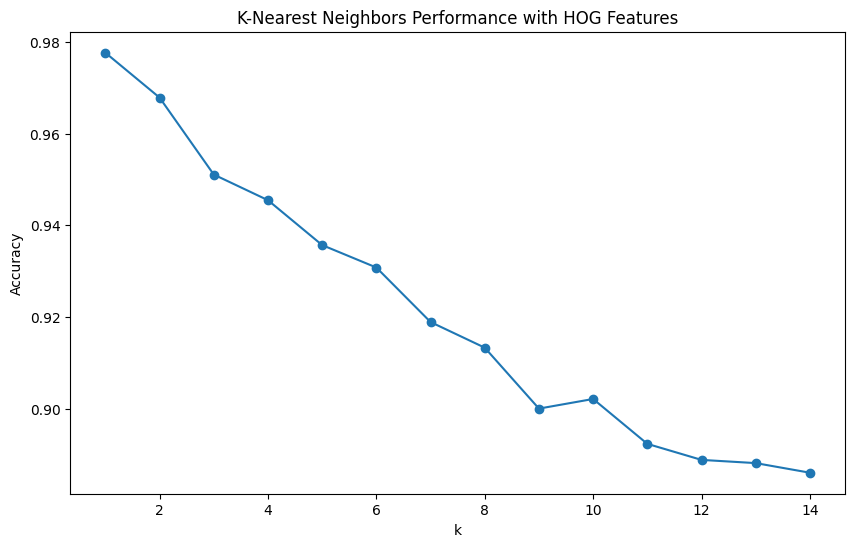

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')


from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(img, orientations=9,pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=-1)
        hog_features.append(features)
    
    return np.array(hog_features)

X_hog_train = extract_hog_features(X_train)
X_hog_test = extract_hog_features(X_test)

scaler = StandardScaler()
X_hog_train_scaled = scaler.fit_transform(X_hog_train)
X_hog_test_scaled = scaler.transform(X_hog_test)

k_values = range(1, 15)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_hog_train_scaled, y_train)
    train_accuracy = knn.score(X_hog_train_scaled, y_train)
    test_accuracy = knn.score(X_hog_test_scaled, y_test)
    accuracies.append(test_accuracy)
    print(f'k={k}, Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}')

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('K-Nearest Neighbors Performance with HOG Features')
plt.show()




### Discussion of Results

Similer to the K-Nearest Neighbors classifier I ran on the data before preprocessing, as the value of *k* increased, the accuracy of the classifier also decreased. However, the knn classifier with preprocessing and the HOG feature extraction applied had an overall higher baseline accuracy with k=1 at 97.76% and k=14 at 88.60% compared to the k=1 accuracy of 95.24% and k=14 accuracy of 80.49% with the knn classifier on the data before preprocessing.

## Visualization of HOG Feature Extraction on Data

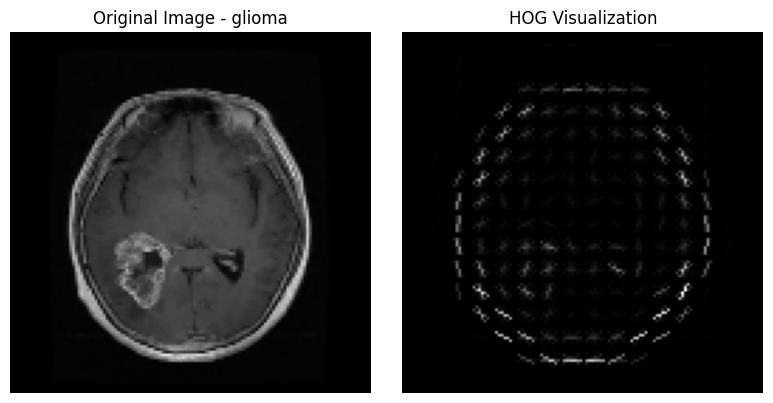

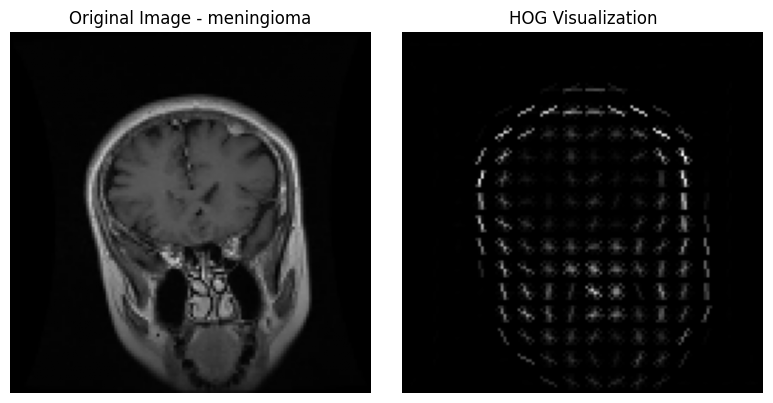

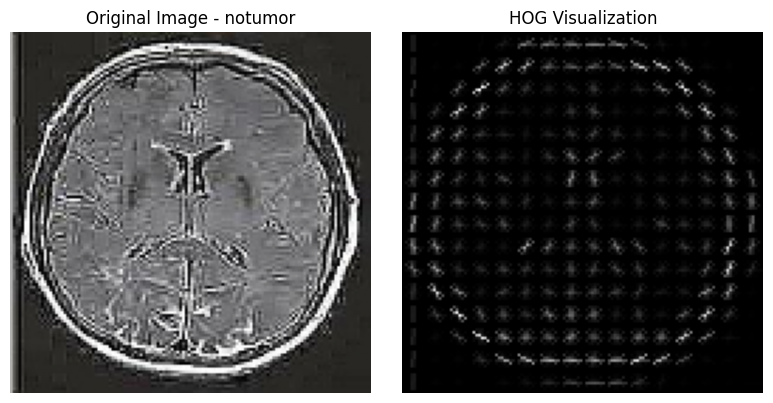

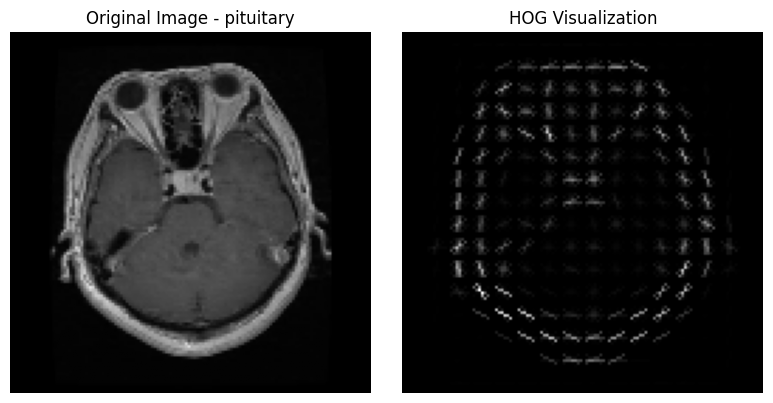

In [25]:
from skimage.feature import hog
from skimage import exposure

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

for i, class_name in enumerate(classes):
    idx = np.where(y_train == class_name)[0][0]
    img = X_train[idx]
    
    features, hog_image = hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=-1, visualize=True)
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f'Original Image - {class_name}')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(exposure.rescale_intensity(hog_image), cmap='gray')
    plt.title('HOG Visualization')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Multi-Layer Preceptron Classification

### Preprocessing Methods

Here I standardized the feature set using a StandardScaler, mirroring the KNN preprocessing approach. I then applied Principal Component Analysis (PCA) to reduce the feature space to 200 components, optimizing my MLP for faster training, improved stability, and better generalization across the dataset.

C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001, Epochs: 10, Validation Accuracy: 0.5100


C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.0001, Epochs: 50, Validation Accuracy: 0.7782


C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


...

Learning Rate: 0.001, Epochs: 50, Validation Accuracy: 0.8926
Learning Rate: 0.001, Epochs: 100, Validation Accuracy: 0.9004
Learning Rate: 0.001, Epochs: 200, Validation Accuracy: 0.9004
Learning Rate: 0.001, Epochs: 500, Validation Accuracy: 0.9004
Learning Rate: 0.001, Epochs: 1000, Validation Accuracy: 0.9004


C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.01, Epochs: 10, Validation Accuracy: 0.9100
Learning Rate: 0.01, Epochs: 50, Validation Accuracy: 0.9153
Learning Rate: 0.01, Epochs: 100, Validation Accuracy: 0.9153
Learning Rate: 0.01, Epochs: 200, Validation Accuracy: 0.9153
Learning Rate: 0.01, Epochs: 500, Validation Accuracy: 0.9153
Learning Rate: 0.01, Epochs: 1000, Validation Accuracy: 0.9153


C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rate: 0.1, Epochs: 10, Validation Accuracy: 0.8524
Learning Rate: 0.1, Epochs: 50, Validation Accuracy: 0.9153
Learning Rate: 0.1, Epochs: 100, Validation Accuracy: 0.9153
Learning Rate: 0.1, Epochs: 200, Validation Accuracy: 0.9153
Learning Rate: 0.1, Epochs: 500, Validation Accuracy: 0.9153
Learning Rate: 0.1, Epochs: 1000, Validation Accuracy: 0.9153

Best Hyperparameters
Learning Rate: 0.01
Epochs: 50
Validation Accuracy: 0.9153

Final Test Results
Test Accuracy: 0.8909


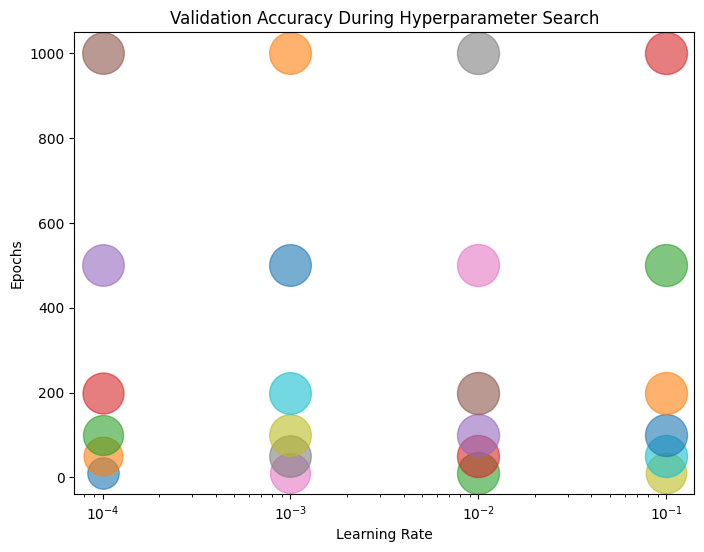

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2


def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []

    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)

        if not os.path.isdir(class_path):
            continue

        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                img = img / 255.0

                images.append(img)
                labels.append(class_folder)

    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')

from sklearn.model_selection import train_test_split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
X_train_sub_flat = X_train_sub.reshape(X_train_sub.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)


from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub_flat)
X_val_scaled = scaler.transform(X_val_flat)


from sklearn.decomposition import PCA
pca = PCA(n_components=200)
X_train_sub_pca = pca.fit_transform(X_train_sub_scaled)
X_val_pca = pca.transform(X_val_scaled)


from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]
epoch_values = [10, 50, 100, 200, 500, 1000]

best_accuracy = 0
best_lr = None
best_epochs = None

results = []

for lr in learning_rates:
    for epochs in epoch_values:

        mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam', learning_rate_init=lr, max_iter=epochs, random_state=42)
        mlp.fit(X_train_sub_pca, y_train_sub)
        y_val_pred = mlp.predict(X_val_pca)
        val_accuracy = accuracy_score(y_val, y_val_pred)
        results.append((lr, epochs, val_accuracy))

        print(f"Learning Rate: {lr}, "f"Epochs: {epochs}, "f"Validation Accuracy: {val_accuracy:.4f}")

        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_lr = lr
            best_epochs = epochs

print("\nBest Hyperparameters")
print(f"Learning Rate: {best_lr}")
print(f"Epochs: {best_epochs}")
print(f"Validation Accuracy: {best_accuracy:.4f}")


X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_flat)
X_test_scaled = scaler_final.transform(X_test_flat)

pca_final = PCA(n_components=200)

X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

final_model = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam', learning_rate_init=best_lr, max_iter=best_epochs, random_state=42)
final_model.fit(X_train_pca, y_train)
y_test_pred = final_model.predict(X_test_pca)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nFinal Test Results")
print(f"Test Accuracy: {test_accuracy:.4f}")


plt.figure(figsize=(8, 6))

for lr, epochs, acc in results:
    plt.scatter(lr, epochs, s=acc * 1000, alpha=0.6)

plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Epochs')
plt.title('Validation Accuracy During Hyperparameter Search')

plt.show()


### Discussion of Results

For this baseline trial, I ran a built-in MLP classifier from sklearn.neural_network over my data. I iterated over 4 separate learning rates (0.0001, 0.001, 0.01, 0.1) and 6 different epochs (10, 50, 100, 200, 500, 1000) to find the optimal parameters for my neural network. I found the best parameters were a learning rate of 0.01 and 50 epochs for a best validation accuracy of 91.53% and a final test accuracy of 89.09%. The parameters with the worst accuracy were a learning rate of 0.0001 and 10 epochs at 51%.

The chart shows that the MLP classifier performed best at moderate learning rates and epochs, particularly around a learning rate of 0.01 and 50 epochs, where the largest bubbles indicate the highest accuracies. Very low learning rates and low epoch counts resulted in poor performance, while excessively high learning rates such as 0.1 generally reduced model accuracy due to unstable learning.


## MLP Importance Heatmap Visualization

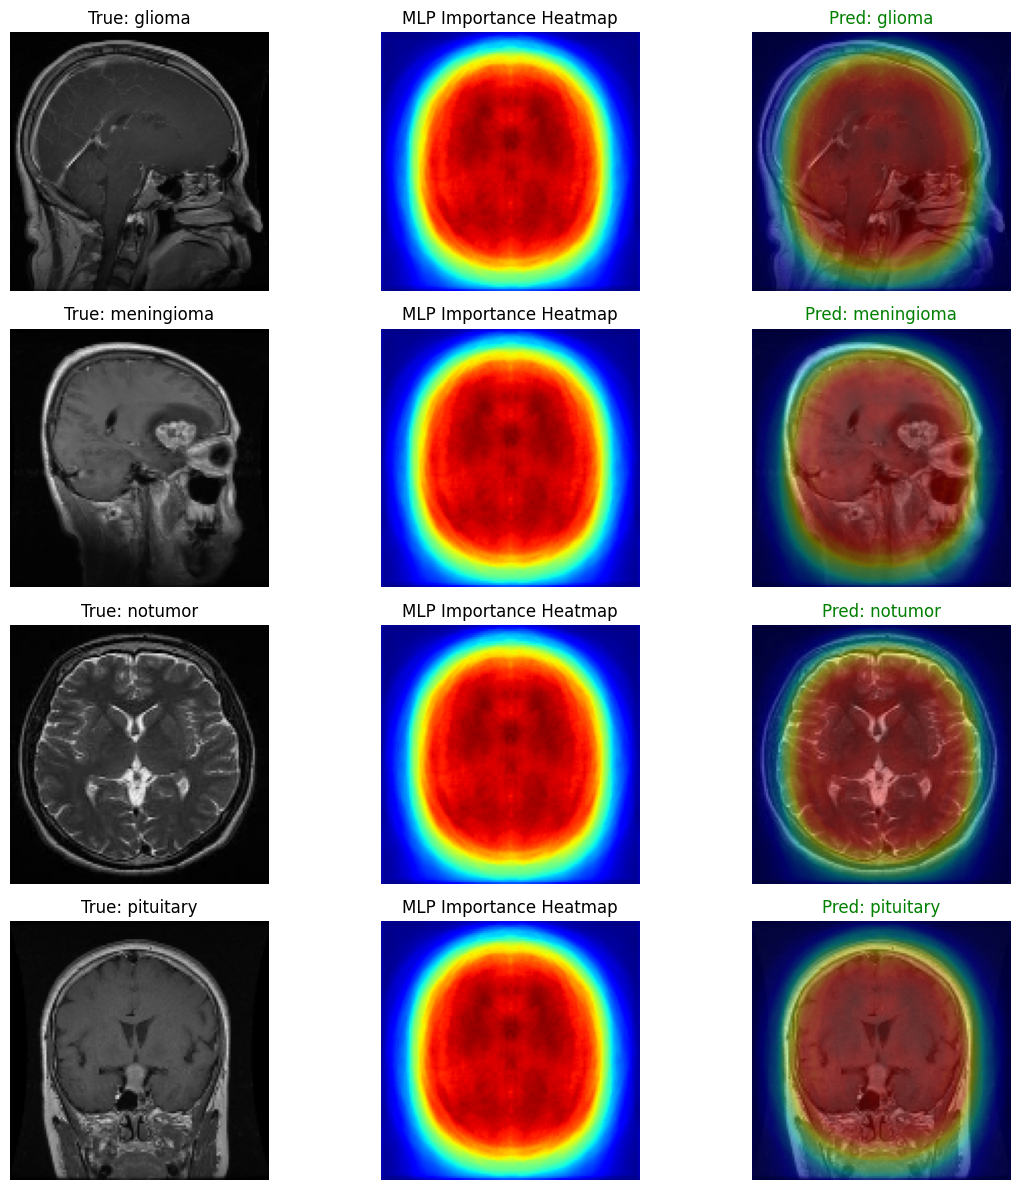

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1))

from sklearn.decomposition import PCA
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam', learning_rate_init=0.01, max_iter=50, random_state=42)
mlp.fit(X_train_pca, y_train)
y_pred = mlp.predict(X_test_pca)
accuracy = accuracy_score(y_test, y_pred)

weights = mlp.coefs_[0]
pca_importance = np.mean(np.abs(weights), axis=1)
important_pix = pca.inverse_transform([pca_importance])[0]


important_pix = scaler.inverse_transform([important_pix])[0]
importance_map = important_pix.reshape(128, 128, 3)
importance_map = np.mean(np.abs(importance_map), axis=2)


importance_map -= importance_map.min()
importance_map /= importance_map.max()

unique_classes = np.unique(y_test)

selected_indices = []

for class_name in unique_classes:
    class_indices = np.where(y_test == class_name)[0]
    chosen_idx = np.random.choice(class_indices)
    selected_indices.append(chosen_idx)

num_images = len(selected_indices)

plt.figure(figsize=(12, num_images * 3))

for i, idx in enumerate(selected_indices):
    original_img = X_test[idx]
    heatmap = cv2.resize(importance_map, (128, 128))
    heatmap_colored = plt.get_cmap('jet')(heatmap)[:, :, :3]

    overlay = (0.6 * original_img + 0.4 * heatmap_colored)
    overlay = np.clip(overlay, 0, 1)

    pred_label = y_pred[idx]
    true_label = y_test[idx]

    color = 'green' if pred_label == true_label else 'red'
    
    plt.subplot(num_images, 3, i * 3 + 1)
    plt.imshow(original_img)
    plt.title(f"True: {true_label}")
    plt.axis('off')
    plt.subplot(num_images, 3, i * 3 + 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("MLP Importance Heatmap")
    plt.axis('off')
    plt.subplot(num_images, 3, i * 3 + 3)
    plt.imshow(overlay)
    plt.title(f"Pred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()




## Discussion

Here I made an approximate feature-importance heatmap for the MLP by projecting the learned feature weights back into image space through inverse PCA transformation. This visualization provides insight into which regions of the MRI images contributed most strongly to the model’s predictions.


## Convolutional Neural Network Classification

### Preprocessing Methods

Here I standardized the feature set using a StandardScaler, similar to the MLP and KNN classifiers above. I then used a LabelEncoder from sklearn.preprocessing to convert my labels like "glioma" or "meningioma" into distinct numerical values, such as 0, 1, 2, and 3, because the mathematical architecture of a CNN requires numerical inputs to calculate loss and update its weights during training.


Training model with learning rate = 0.0001


C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.5393 - loss: 1.0673 - val_accuracy: 0.7310 - val_loss: 0.8058
Epoch 2/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.7060 - loss: 0.7747 - val_accuracy: 0.7913 - val_loss: 0.6531
Epoch 3/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.7630 - loss: 0.6458 - val_accuracy: 0.8148 - val_loss: 0.5436
Epoch 4/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.7886 - loss: 0.5792 - val_accuracy: 0.8227 - val_loss: 0.5034
Epoch 5/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8012 - loss: 0.5517 - val_accuracy: 0.8419 - val_loss: 0.5137
Epoch 6/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8104 - loss: 0.5079 - val_accuracy: 0.8489 - val_loss: 0.4306
Epoch 7/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8322 - loss: 0.4676 - val_accuracy: 0.8498 - val_loss: 0.4309
Epoch 8/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8440 - loss: 0.4219 - 

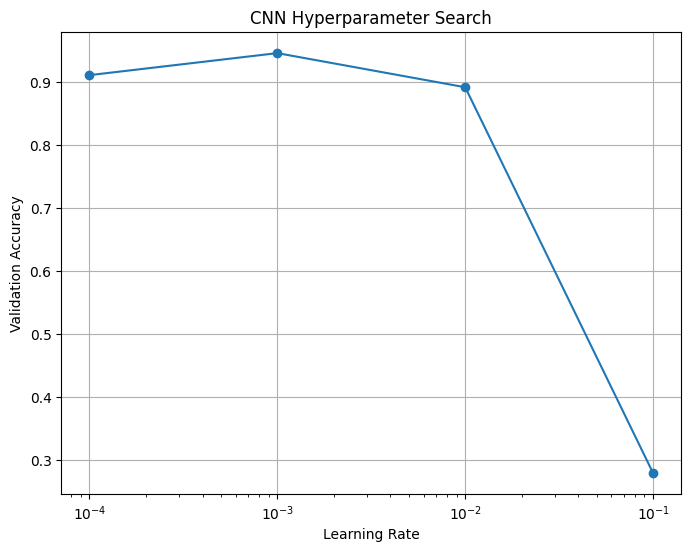

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2


def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []

    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)

        if not os.path.isdir(class_path):
            continue

        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                img = img / 255.0

                images.append(img)
                labels.append(class_folder)

    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')



from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

from sklearn.model_selection import train_test_split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train_encoded, test_size=0.2, random_state=42, stratify=y_train_encoded)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]

best_accuracy = 0
best_lr = None

results = []

for lr in learning_rates:

    print(f"\nTraining model with learning rate = {lr}")

    model = Sequential([Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)), MaxPooling2D((2, 2)),
                        Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)), Flatten(),
                        Dense(64, activation='relu'), Dropout(0.5), Dense(4, activation='softmax')])


    model.compile(optimizer=Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train_sub, y_train_sub, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=1)
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    results.append((lr, val_acc))
    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_lr = lr

print("\nBest Hyperparameter")
print(f"Learning Rate = {best_lr}")
print(f"Validation Accuracy = {best_accuracy:.4f}")


final_model = Sequential([Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)), MaxPooling2D((2, 2)),
                         Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)), Flatten(),
                         Dense(64, activation='relu'), Dropout(0.5), Dense(4, activation='softmax')])

final_model.compile(optimizer=Adam(learning_rate=best_lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
final_model.fit(X_train, y_train_encoded, epochs=30, batch_size=32, verbose=1)
test_loss, test_acc = final_model.evaluate(X_test, y_test_encoded, verbose=0)

print("\nFinal Test Results")
print(f"Test Accuracy: {test_acc:.4f}")


plt.figure(figsize=(8, 6))

learning_rates_plot = [lr for lr, acc in results]
accuracies_plot = [acc for lr, acc in results]

plt.plot(learning_rates_plot, accuracies_plot, marker='o')
plt.xscale('log')
plt.xlabel('Learning Rate')
plt.ylabel('Validation Accuracy')
plt.title('CNN Hyperparameter Search')

plt.grid(True)
plt.show()

### Discussion of Results

For this trial, I implemented a simple CNN classifier over my dataset. I iterated over 4 different learning rates (0.0001, 0.001, 0.01, 0.1) for a fixed number of 30 epochs for each learning rate. The learning rate of 0.001 provided the best balance between learning efficiency and model stability, achieving the highest validation accuracy of 94.59% during hyperparameter tuning. In comparison, the lower learning rate of 0.0001 produced steady but slower learning, reaching a validation accuracy of 91.09%, suggesting that additional training epochs may have further improved performance. Conversely, the higher learning rates of 0.01 and 0.1 led to unstable optimization and poor convergence, with the model trained at 0.1 performing near chance level and achieving only 24–28% validation accuracy. These results highlight the importance of selecting an appropriate learning rate, as values that are too small can slow learning while excessively large values can prevent convergence altogether. Using the optimal learning rate of 0.001, the final CNN demonstrated strong generalization to unseen data, achieving a high test accuracy of 96.01%.

## Grad-CAM Visualization of CNN on fMRI Images

Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6781 - loss: 0.7848 - val_accuracy: 0.8105 - val_loss: 0.5418
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.8274 - loss: 0.4497 - val_accuracy: 0.8657 - val_loss: 0.3780
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.8707 - loss: 0.3368 - val_accuracy: 0.9112 - val_loss: 0.2420
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8990 - loss: 0.2555 - val_accuracy: 0.9056 - val_loss: 0.2702
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9256 - loss: 0.1989 - val_accuracy: 0.9231 - val_loss: 0.2126
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9348 - loss: 0.1647 - val_accuracy: 0.9385 - val_loss: 0.1802
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9472 - loss: 0.1302 - val_accuracy: 0.9434 - val_loss: 0.1751
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 13s 71ms/step - accuracy: 0.9547 - loss: 0.1207 - 

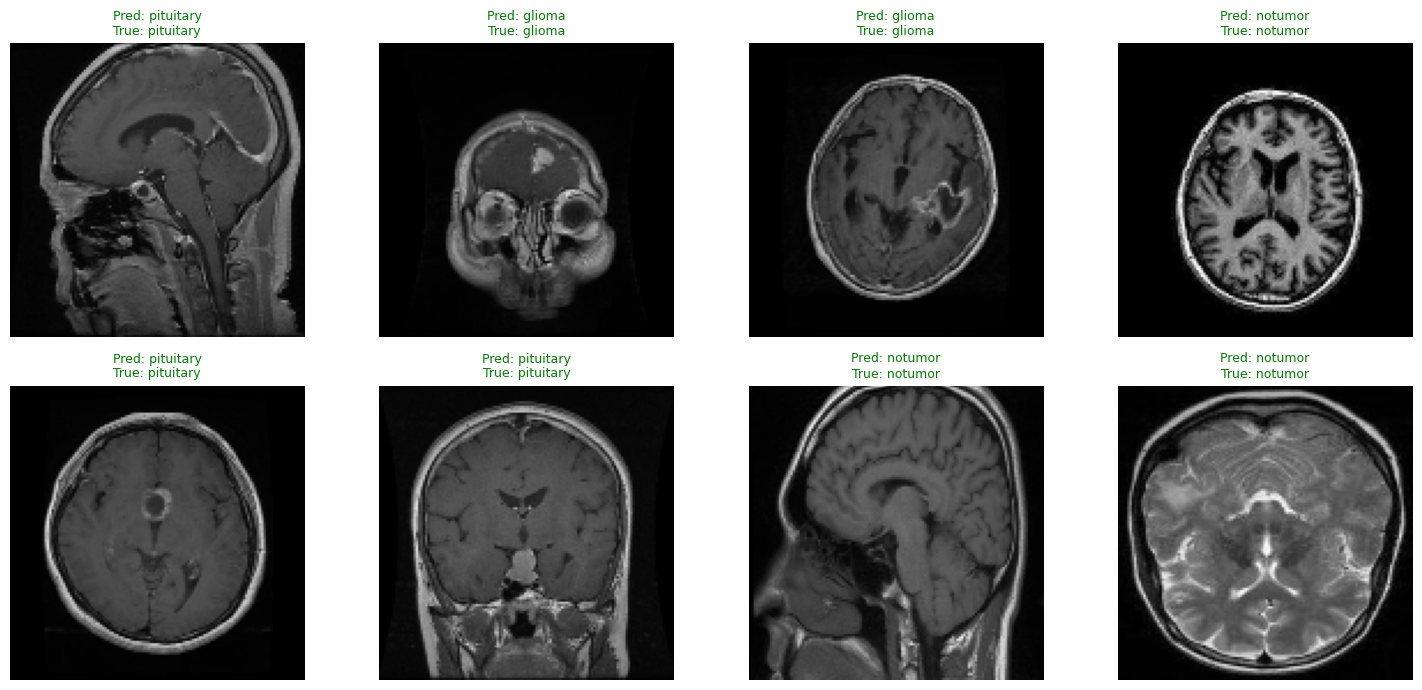

C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_226']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_226']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)
C:\Users\ben_n\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_226']
Received: inp

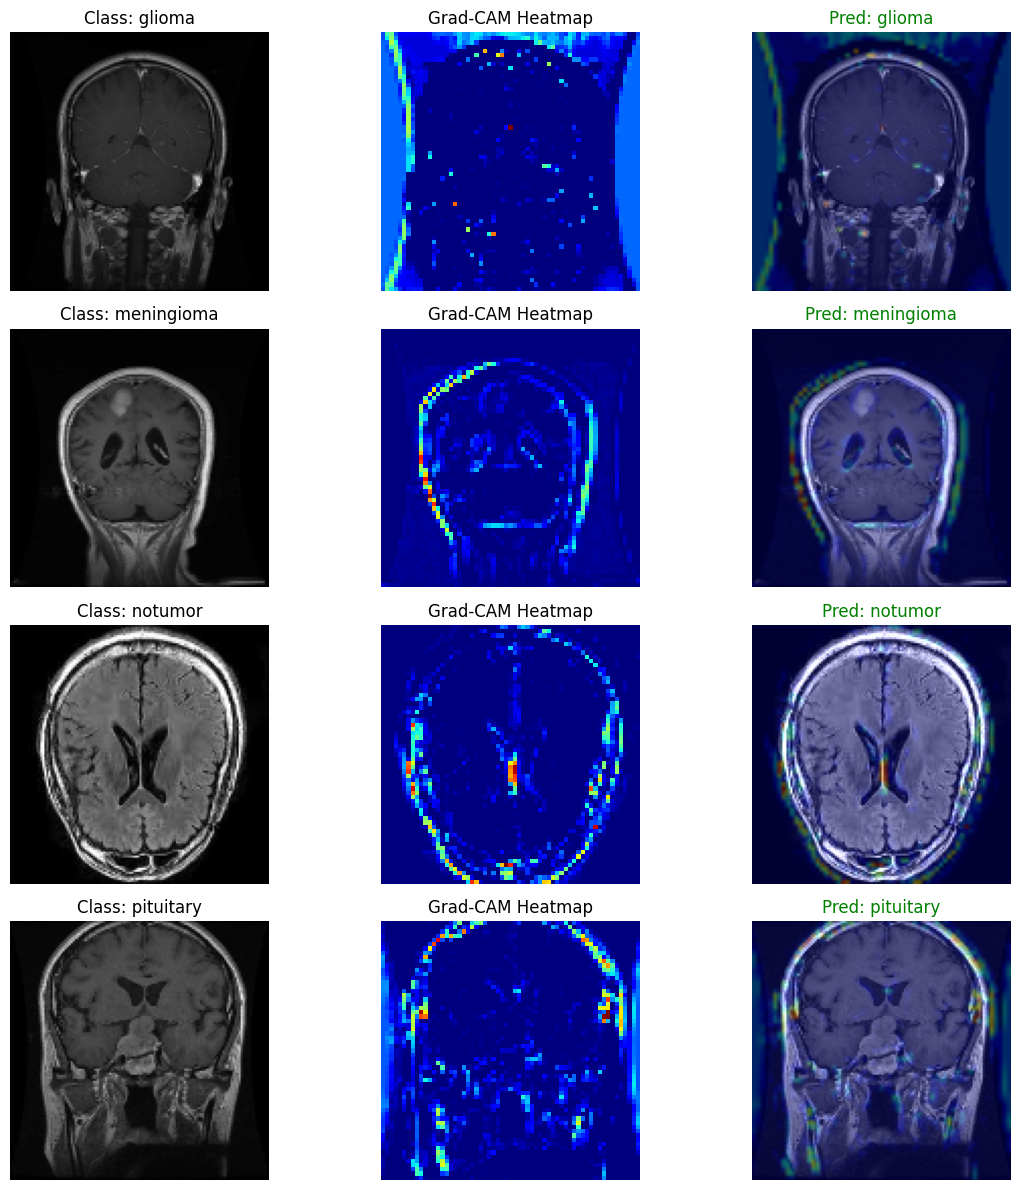

In [19]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.preprocessing import StandardScaler, LabelEncoder

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1))

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([Input(shape=(128, 128, 3)), Conv2D(32, (3, 3), activation='relu', name='conv1'),
                    MaxPooling2D((2, 2)), Conv2D(64, (3, 3), activation='relu', name='conv2'),
                    MaxPooling2D((2, 2)), Flatten(), Dense(64, activation='relu'), Dropout(0.5),
                    Dense(4, activation='softmax')])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_encoded, epochs=30, batch_size=32, validation_data=(X_test, y_test_encoded))
test_loss, test_acc = model.evaluate(X_test, y_test_encoded, verbose=0)

print(f"Test Accuracy: {test_acc:.4f}")

predictions = model.predict(X_test, verbose=0)
predicted_indices = np.argmax(predictions, axis=1)
predicted_class_names = le.inverse_transform(predicted_indices)
actual_class_names = y_test

num_images = 8
random_indices = np.random.choice(len(X_test), num_images, replace=False)

plt.figure(figsize=(15, 7))

for i, idx in enumerate(random_indices):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[idx])

    pred_label = predicted_class_names[idx]
    true_label = actual_class_names[idx]
    color = 'green' if pred_label == true_label else 'red'

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=9)

    plt.axis('off')

plt.tight_layout()
plt.show()


class_names = le.classes_

class_images = {}
class_indices = {}

for cls in class_names:
    idx = np.where(y_test == cls)[0][0]
    class_images[cls] = X_test[idx]
    class_indices[cls] = idx



last_conv_layer_name = "conv2"

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = Model(inputs=model.inputs, outputs=[model.get_layer(last_conv_layer_name).output, model.outputs[0]])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)

    if max_val == 0:
        return np.zeros(heatmap.shape)
    
    heatmap /= max_val
    return heatmap.numpy()


def display_gradcam(img, heatmap, alpha=0.4):

    heatmap = np.uint8(255 * heatmap)

    cmap = plt.get_cmap("jet")
    heatmap_colors = cmap(heatmap)[:, :, :3]
    heatmap_colors = cv2.resize(heatmap_colors, (img.shape[1], img.shape[0]))

    overlay = (heatmap_colors * alpha + img)
    overlay = np.clip(overlay, 0, 1)

    return overlay

plt.figure(figsize=(12, len(class_names) * 3))

for i, cls in enumerate(class_names):

    img = class_images[cls]
    idx = class_indices[cls]

    img_array = np.expand_dims(img, axis=0)
    preds = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(preds[0])
    pred_label = le.inverse_transform([pred_idx])[0]
    true_label = cls

    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=pred_idx)

    cam_img = display_gradcam(img, heatmap)

    plt.subplot(len(class_names), 3, i * 3 + 1)
    plt.imshow(img)
    plt.title(f"Class: {true_label}")
    plt.axis('off')

    plt.subplot(len(class_names), 3, i * 3 + 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')
    plt.subplot(len(class_names), 3, i * 3 + 3)
    plt.imshow(cam_img)
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Discussion

The purpose of this is to help you visualize the "behind the scenes" of the CNN I have trained over the fMRI data. The first figure is a to show the comparison between the true label and the CNN's prediction over 8 different images from my test dataset.


The second figure presents Grad-CAM visualizations superimposed on the original MRI images, highlighting the regions that most strongly influenced the CNN’s predictions. These heatmaps demonstrate how the network learns low-level image features such as edges, textures, and intensity transitions while refining important spatial structures related to tumor classification.


## Visualization of Classification and Misclassification

\* All models in this section were ran with the optimal hyperparameters found above\*

### Confusion Matrix for KNN Before Preprocessing


Classification Report:
              precision    recall  f1-score   support

      glioma       0.94      0.96      0.95       324
  meningioma       0.95      0.90      0.93       355
     notumor       0.97      0.95      0.96       400
   pituitary       0.95      0.99      0.97       351

    accuracy                           0.95      1430
   macro avg       0.95      0.95      0.95      1430
weighted avg       0.95      0.95      0.95      1430



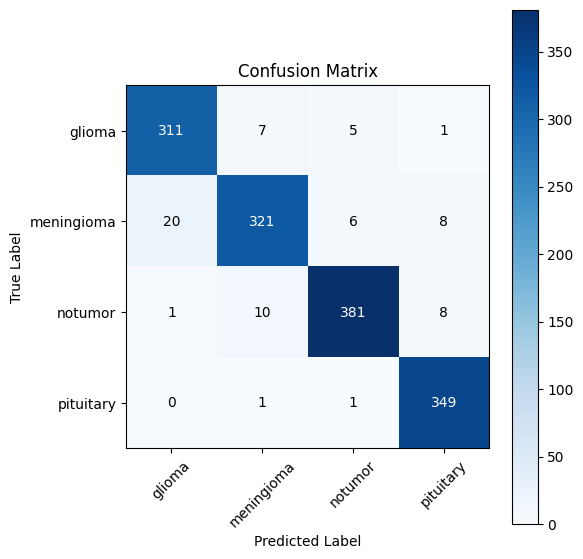

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.metrics import confusion_matrix, classification_report

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')


from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train.reshape(X_train.shape[0], -1), y_train)
y_pred = knn.predict(X_test.reshape(X_test.shape[0], -1))


conf_matrix = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



### Discussion

As you can see from the results of the KNN classifier before preprocessing, the model shows 95% accuracy when it comes to predicting the correct tumor. The confusion matrix shows that the classifier correctly identified most samples, as seen by the large values down the diagonal. Glioma cases were classified correctly 311 times, but 7 were mistaken for meningioma and 5 for notumor. Meningioma cases were classified correctly 321 times, but had the highest misclassification rate. Twentey samples were incorrectly predicted as glioma and smaller errors spread across notumor and pituitary, indicating that the model struggled most to distinguish meningioma tumors from glioma tumors, likely due to similar features and similar locations in the brain on the fMRI scans. Pituitary tumors were classified extremely well with 349 correct predicitons and only 2 total misclassifications as meningioma and notumor. The notumor class also performed well with 381 correct predictions and 5 misclassifications with glioma tumors, 6 with meningioma tumors, and only 1 with pituitary.

### Confusion Matrix for KNN with Preprocessing and HOG Feature Extraction


Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.98      0.98       324
  meningioma       0.97      0.95      0.96       355
     notumor       0.98      0.97      0.98       400
   pituitary       0.97      1.00      0.99       351

    accuracy                           0.98      1430
   macro avg       0.98      0.98      0.98      1430
weighted avg       0.98      0.98      0.98      1430



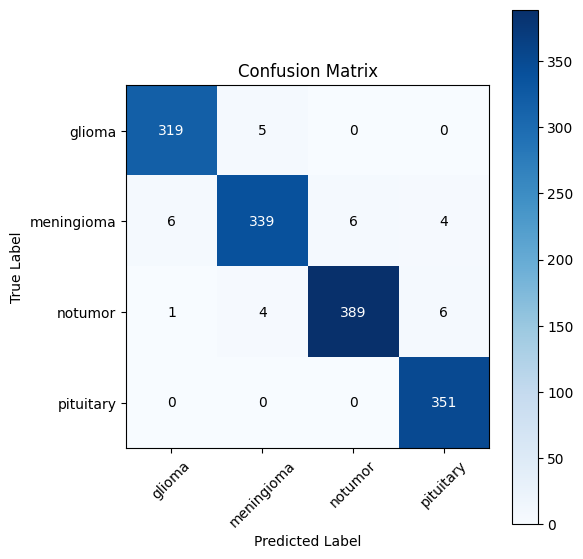

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.metrics import confusion_matrix, classification_report

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')


from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(img, orientations=9,pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=-1)
        hog_features.append(features)
    
    return np.array(hog_features)

X_hog_train = extract_hog_features(X_train)
X_hog_test = extract_hog_features(X_test)

scaler = StandardScaler()
X_hog_train_scaled = scaler.fit_transform(X_hog_train)
X_hog_test_scaled = scaler.transform(X_hog_test)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_hog_train_scaled, y_train)
y_pred = knn.predict(X_hog_test_scaled.reshape(X_hog_test_scaled.shape[0], -1))

conf_matrix = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()





### Discussion

As you can see from the results of the KNN classifier with preprocessing and HOG feature extraction, the model shows strong predictive power with 98% accuracy, showing improvement from 95% with the KNN applied before preprocessing. The confusion matrix shows a noticeable improvement compared the the KNN classifier applied before preprocessing, with higher diagonal values and less misclassifications. Glioma predictions improved from 311 to 319 correct classifications, with only 5 cases confused with meningioma and no misclassifications in notumor and pituitary. Meningioma performance improved from 321 to 339, and reduced glioma misclassification from 20 down to 6, and only had 6 incorrect in notumor and 4 in pituitary. The notumor class improved from 381 to 389, with confusion only with meningioma tumors, likely due to proximate location in the brain on the fMRI scans. The pituitary class achieved perfect classificiation with all 351 samples identified correctly and zero misclassifications compared to the two misclassifications from the KNN before preprocessing.

### Confusion Matrix for MLP


Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.90      0.90       324
  meningioma       0.89      0.84      0.87       355
     notumor       0.93      0.96      0.95       400
   pituitary       0.97      0.98      0.97       351

    accuracy                           0.92      1430
   macro avg       0.92      0.92      0.92      1430
weighted avg       0.92      0.92      0.92      1430



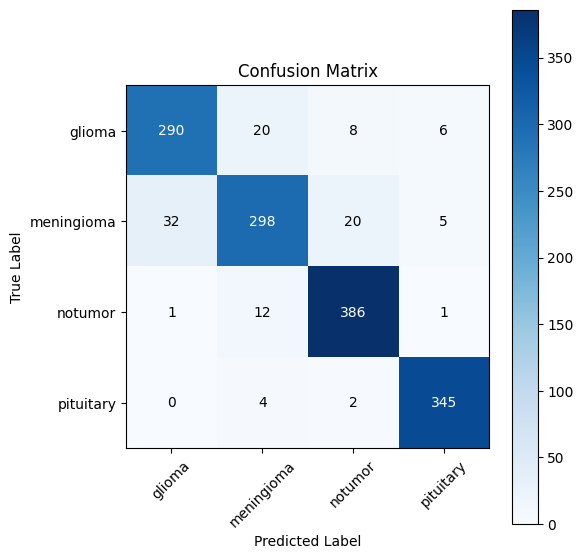

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.metrics import confusion_matrix, classification_report

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1))

from sklearn.decomposition import PCA
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)


from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam', learning_rate_init=0.01, max_iter=50, random_state=42)
mlp.fit(X_train_pca, y_train)
y_pred = mlp.predict(X_test_pca)

conf_matrix = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()




### Discussion

As you can see from the results of the Multi-Layer Preceptron (MLP), the model exhibits 92% accuracy when it comes to classifying tumors from fMRI scans. The confusion matrix shows that the classifier correctly identified most samples, as seen by the large values down the diagonal. Glioma cases were classified correctly 290 times, but had the highest misclassification rate as 32 were mistaken for meningioma and 1 for notumor, idicating that the model struggled most to distinguish meningioma tumors from glioma tumors, likely due to non-linear features, similar features, and similar locations in the brain on the fMRI scans. Meningioma cases were classified correctly 298 times, but had a slightly smaller misclassification rate. Twenty samples were incorrectly predicted as glioma, 12 for notumor, and 4 for pituitary, confirming that the model struggled most to distinguish meningioma tumors from glioma tumors. Pituitary tumors were classified extremely well with 345 correct predicitons, but had 6 misclassifications for glioma, 5 for meningioma, and only 1 for notumor. The notumor class also performed well with 386 correct predictions, but had 20 misclassifications with meningioma tumors, 8 with glioma tumors, and only 2 with pituitary, indicating the model also had struggles distinguishing meningioma tumors from a healthy brain with no tumors. 


### Confusion Matrix for CNN

Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.6739 - loss: 0.8056 - val_accuracy: 0.8070 - val_loss: 0.4543
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.8115 - loss: 0.4781 - val_accuracy: 0.8832 - val_loss: 0.3163
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.8700 - loss: 0.3351 - val_accuracy: 0.9077 - val_loss: 0.2557
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.8861 - loss: 0.2679 - val_accuracy: 0.9154 - val_loss: 0.2362
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.9098 - loss: 0.2288 - val_accuracy: 0.9378 - val_loss: 0.1800
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9245 - loss: 0.1905 - val_accuracy: 0.9441 - val_loss: 0.1711
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9296 - loss: 0.1652 - val_accuracy: 0.9503 - val_loss: 0.1638
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.9439 - loss: 0.1387 - 

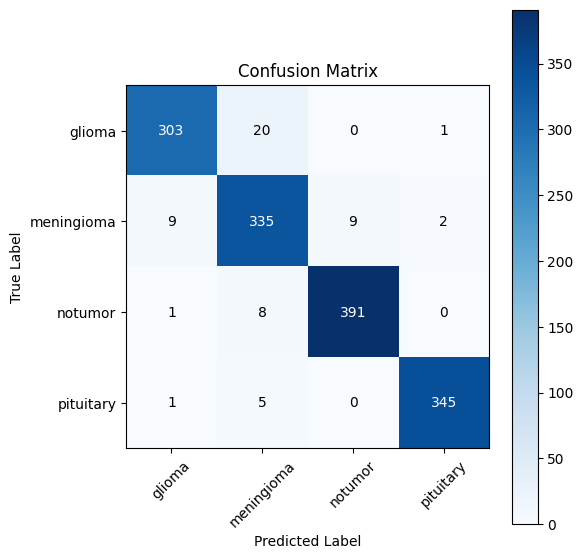

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.preprocessing import StandardScaler, LabelEncoder

def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []
    
    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)
        
        if not os.path.isdir(class_path):
            continue
        
        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)
            
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                resized_img = cv2.resize(img, target_size)
                resized_img = resized_img / 255.0
                
                images.append(resized_img)
                labels.append(class_folder)
    
    return np.array(images), np.array(labels)

X_train, y_train = load_images('fMRI data/train')
X_test, y_test = load_images('fMRI data/test')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(X_train.shape[0], -1))
X_test_scaled = scaler.transform(X_test.reshape(X_test.shape[0], -1))

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([Input(shape=(128, 128, 3)), Conv2D(32, (3, 3), activation='relu', name='conv1'),
                    MaxPooling2D((2, 2)), Conv2D(64, (3, 3), activation='relu', name='conv2'),
                    MaxPooling2D((2, 2)), Flatten(), Dense(64, activation='relu'), Dropout(0.5),
                    Dense(4, activation='softmax')])

model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_encoded, epochs=30, batch_size=32, validation_data=(X_test, y_test_encoded))
test_loss, test_acc = model.evaluate(X_test, y_test_encoded, verbose=0)

from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(y_test_encoded, model.predict(X_test).argmax(axis=1))
classes = le.classes_

print("\nClassification Report:")
print(classification_report(y_test_encoded, model.predict(X_test).argmax(axis=1), target_names=classes))

plt.figure(figsize=(6, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()



### Discussion

As you can see from the results of my Convolutional Neural Network (CNN), it performed extremely well, improving to 96% from 89% with the MLP classifier. The confusion matrix shows that the classifier correctly identified most samples, as seen by the large values down the diagonal. Glioma predictions improved from 290 to 303 correct classifications, with only 9 cases confused with meningioma from 32, and only 1 misclassification in notumor and pituitary. Meningioma performance improved from 298 to 335 correct prediction, but glioma misclassification remained the same with 20, showing that both models struggled to distinguish meningioma tumors form glioma tumors. Furthermore, the CNN only had 8 incorrect in notumor and 5 in pituitary for the meningioma class. The notumor class improved from 386 to 391, with confusion only with meningioma tumors, likely due to small features, unrecognizable to the CNN. The pituitary class performed the same as the MLP, but reduced notumor misclassification to 0 from 1, meningioma to 2 from 5, and glioma to 1 from 4.

### ROC Curve Comparison of Two Best Classifiers: KNN and CNN

A Receiver Operating Characteristic (ROC) curve, is a graphical representation that illustrates the performance of a binary classification model by plotting the true positive rate against the false positive rate at various threshold settings.

KNN Accuracy: 0.9776223776223776
Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.6481 - loss: 0.8313 - val_accuracy: 0.8252 - val_loss: 0.5015
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.7984 - loss: 0.5109 - val_accuracy: 0.8657 - val_loss: 0.3631
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.8419 - loss: 0.3913 - val_accuracy: 0.8748 - val_loss: 0.3111
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.8759 - loss: 0.3011 - val_accuracy: 0.9077 - val_loss: 0.2585
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.8908 - loss: 0.2647 - val_accuracy: 0.9336 - val_loss: 0.2063
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9081 - loss: 0.2278 - val_accuracy: 0.9266 - val_loss: 0.2121
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9200 - loss: 0.1979 - val_accuracy: 0.9301 - val_loss: 0.2009
Epoch 8/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - a

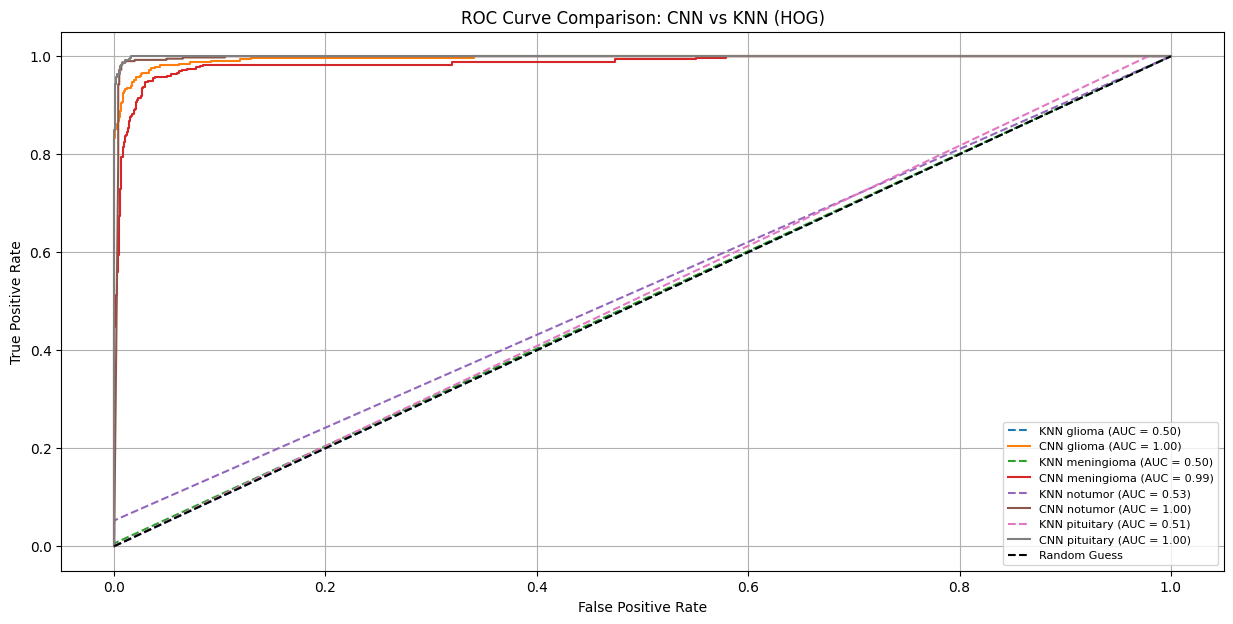

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2


def load_images(folder, target_size=(128, 128)):
    images = []
    labels = []

    for class_folder in os.listdir(folder):
        class_path = os.path.join(folder, class_folder)

        if not os.path.isdir(class_path):
            continue

        for filename in sorted(os.listdir(class_path)):
            img_path = os.path.join(class_path, filename)
            img = cv2.imread(img_path)

            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                img = img / 255.0

                images.append(img)
                labels.append(class_folder)

    return np.array(images), np.array(labels)


X_train, y_train = load_images("fMRI data/train")
X_test, y_test = load_images("fMRI data/test")

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from skimage.feature import hog

def extract_hog_features(images):
    hog_features = []
    for img in images:
        features = hog(img, orientations=9,pixels_per_cell=(8, 8), cells_per_block=(2, 2), channel_axis=-1)
        hog_features.append(features)
    
    return np.array(hog_features)

X_hog_train = extract_hog_features(X_train)
X_hog_test = extract_hog_features(X_test)

scaler = StandardScaler()
X_hog_train_scaled = scaler.fit_transform(X_hog_train)
X_hog_test_scaled = scaler.transform(X_hog_test)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_hog_train_scaled, y_train)
y_pred = knn.predict(X_hog_test_scaled.reshape(X_hog_test_scaled.shape[0], -1))
knn_acc = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", knn_acc)


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

cnn = Sequential([Input(shape=(128, 128, 3)), Conv2D(32, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
                    Conv2D(64, (3, 3), activation='relu'), MaxPooling2D((2, 2)), Flatten(), Dense(64, activation='relu'),
                    Dropout(0.5), Dense(len(le.classes_), activation='softmax')])

cnn.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train_enc, epochs=30, batch_size=32, validation_data=(X_test, y_test_enc), verbose=1)
loss, cnn_acc = cnn.evaluate(X_test, y_test_enc, verbose=0)

y_pred_cnn = np.argmax(cnn.predict(X_test), axis=1)
y_pred_cnn_labels = le.inverse_transform(y_pred_cnn)

print("CNN Accuracy:", cnn_acc)


from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

class_names = le.classes_
n_classes = len(class_names)

y_test_bin = label_binarize(y_test, classes=class_names)

knn_probs = knn.predict_proba(X_hog_test)
cnn_probs = cnn.predict(X_test)


plt.figure(figsize=(15, 7))
for i in range(n_classes):
    fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, i], knn_probs[:, i])
    roc_auc_knn = auc(fpr_knn, tpr_knn)

    plt.plot(fpr_knn, tpr_knn, linestyle='--', label=f"KNN {class_names[i]} (AUC = {roc_auc_knn:.2f})")
    fpr_cnn, tpr_cnn, _ = roc_curve(y_test_bin[:, i], cnn_probs[:, i])
    roc_auc_cnn = auc(fpr_cnn, tpr_cnn)

    plt.plot(fpr_cnn, tpr_cnn, label=f"CNN {class_names[i]} (AUC = {roc_auc_cnn:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.title("ROC Curve Comparison: CNN vs KNN (HOG)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)
plt.show()

### Discussion

Based on the ROC curve, the CNN outperforms the KNN model across all tumor classification categories. The CNN achieves near-perfect diagnostic capability, as it is in the top-left corner with Area Under the Curve (AUC) scores ranging from 0.99 to 1.00 for the glioma, meningioma, notumor, and pituitary classes. Unlike the CNN, the KNN model performs no better than a random guess, as its dashed curves closely follow a linear, diagonal baseline with AUC scores flat-lining between 0.50 and 0.53. This indicates that the deep learning CNN architecture is highly effective at extracting the complex features necessary for fMRI image analysis, while the traditional KNN approach fails to distinguish between the different conditions.

## Conclusion

The results show that both traditional machine learning and deep learning models can classify brain tumor fMRI images with high accuracy, but deep learning methods performed more reliably. The KNN classifier achieved strong baseline performance, improving from 95.24% accuracy before preprocessing to 97.76% after preprocessing and HOG feature extraction, showing that feature engineering actually improved traditional machine learning performance. 

The MLP neural network achieved a lower optimal accuracy of 89.09% and struggled most with distinguishing glioma and meningioma tumors. The CNN produced the strongest deep learning performance, achieving 96.01% accuracy and near-perfect ROC AUC scores between 0.99 and 1.00. The confusion matrices showed that the CNN reduced misclassifications compared to the MLP, especially for difficult tumor classes. What was a very interesting finding for me, as revealed by the ROC curve, was although KNN achieved a slightly higher accuracy than the CNN, its ROC curves suggested weak class separation, demonstrating the accuracy paradox, where a model can appear highly accurate while still performing poorly at true classification. These findings suggest that accuracy alone can be misleading, particularly in medical datasets where class imbalances may exist.

Overall, the CNN proved to be the most reliable and effective model for brain tumor classification because it successfully learned the complex visual patterns necessary for accurate fMRI image analysis, while the traditional KNN approach relied more on preprocessing and feature extraction, and still struggled to generalize effectively.